## Robustness and Comparative Analysis

This notebook implements a robustness check for the counterfactual framework applied to the Fuel Tank Filter case study: a **SHAP-naive baseline**, quantifying the added value of the counterfactual module over a naive decision rule derived directly from SHAP feature importance (Santos et al.'s Triad+SHAP method).

Uses the original surrogate model (`../models/gbc_best_model.pkl`). Requires scikit-learn `1.4.1.post1` exactly (pinned in `requirements.txt`), as the model was pickled with this version and newer scikit-learn releases (>=1.6) changed the internal `_loss` module in a way that breaks unpickling.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import shap

from sklearn.preprocessing import MinMaxScaler

my_seed = 42
np.random.seed(my_seed)

### Load data (same procedure as `cfs_generation.ipynb`)

In [2]:
data = pd.read_csv('../sim_data/C201905_counterfactuals/simulation_C201905_counterfactuals__ev0.1812.csv', index_col=0)
data['delay'] = (data['actual_duration'] > data['baseline_duration']) * 1
data.drop(columns=['actual_duration', 'baseline_duration', 'critical_path'], inplace=True)
columns_sorted = sorted(data.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data = data[columns_sorted]

def normalize_dataframe(df, feature_range=(0, 1)):
    scaler = MinMaxScaler(feature_range=feature_range)
    normalized_data = scaler.fit_transform(df)
    return pd.DataFrame(normalized_data, columns=df.columns, index=df.index), scaler

def denormalize_dataframe(normalized_df, scaler):
    denormalized_data = scaler.inverse_transform(normalized_df)
    return pd.DataFrame(denormalized_data, columns=normalized_df.columns, index=normalized_df.index)

data_to_normalize = data.iloc[:, :-1]
normalized_data, my_scaler = normalize_dataframe(data_to_normalize)
data = pd.concat([normalized_data, data.iloc[:, -1]], axis=1)

X = data.drop(columns=['delay'])
y = data['delay']

query_instance = X.loc[[11030]]
class_of_query_instance = y.loc[[11030]]
print('Query instance class (1=delay):', class_of_query_instance.values)

Query instance class (1=delay): [1]


### Load the original surrogate model

In [3]:
gbc_model = joblib.load('../models/gbc_best_model.pkl')
print('Prediction on query instance:', gbc_model.predict(query_instance))

Prediction on query instance: [1]


### SHAP analysis of the query instance

Follows the same approach as `sheva_shapley_backward_analysis.ipynb` (Santos et al.'s Triad+SHAP method): instance-level SHAP values via `shap.Explainer`, ranking tasks by their contribution towards the delayed-completion class.

In [4]:
explainer = shap.Explainer(gbc_model, X)
shap_values = explainer(query_instance)

vals = shap_values.values
if vals.ndim == 3:
    vals = vals[:, :, 1]
vals = vals[0]

shap_ranking = pd.Series(vals, index=X.columns).sort_values(ascending=False)
print('SHAP ranking towards delay (highest first):')
print(shap_ranking)

SHAP ranking towards delay (highest first):
duration11    2.969695
duration2     1.109163
duration12    0.135179
duration15    0.015280
duration6     0.007095
duration7     0.005535
duration3     0.002244
duration4     0.002231
duration8     0.000605
duration5    -0.001007
duration9    -0.004275
duration1    -0.006957
duration13   -0.022527
duration10   -0.025067
duration14   -0.349038
dtype: float64


### Naive SHAP-driven baseline

Simulates the decision a manager would make using only the SHAP importance ranking, without the counterfactual search machinery: compress the highest-ranked task progressively towards its optimistic bound ($0.8 \times$ baseline duration) until the surrogate predicts on-time completion. If a single task is not enough, escalate to the next-ranked task, and so on.

The cost function is identical to Equation 1 in the manuscript (`calculate_project_cost` in `cfs_generation.ipynb`).

In [5]:
def calculate_project_cost(instance_duration, base_duration, linear_cost, alpha, beta):
    d = instance_duration.squeeze()
    d_base = base_duration.squeeze()
    c = linear_cost.squeeze()
    d_optimistic = d_base * 0.8
    d_pessimistic = d_base * 1.2
    cost = pd.Series(index=d.index, dtype=float)
    for task in d.index:
        if d[task] < d_base[task]:
            denominator = (d_base[task] - d_optimistic[task]) ** 2
            adjustment = 1 + alpha * (d_base[task] - d[task]) / denominator if denominator != 0 else 1
        else:
            denominator = (d_pessimistic[task] - d_base[task]) ** 2
            adjustment = 1 + beta * (d[task] - d_base[task]) / denominator if denominator != 0 else 1
        cost[task] = d[task] * c[task] * adjustment
    return cost.sum()

costs = [122.77, 151.32, 291.67, 67.88, 2.82, 49.07, 75.00, 6.19, 37.45, 7.90, 9.21, 1554.69, 0.00, 921.30, 0.00]
df_costs = pd.DataFrame([costs], columns=[f"duration{i+1}" for i in range(15)])
base_durations_days = [224, 209, 30, 267, 222, 242, 250, 202, 247, 269, 258, 16, 1, 27, 1]
base_durations_hours = pd.DataFrame([base_durations_days], columns=[f"duration{i+1}" for i in range(15)]) * 8
alpha, beta = 0.1, 0

In [6]:
shap_task_order = [t for t in shap_ranking.index if shap_ranking[t] > 0]
print('Tasks pushing towards delay, in SHAP order:', shap_task_order)

denorm_query = denormalize_dataframe(query_instance, my_scaler)
current_duration = denorm_query.copy()
d_base = base_durations_hours.squeeze()
d_optimistic = d_base * 0.8

flipped = False
tasks_touched = []
STEPS = 50

feature_list = list(X.columns)
for task in shap_task_order:
    tasks_touched.append(task)
    lo, hi = d_optimistic[task], current_duration[task].values[0]
    for step in range(1, STEPS + 1):
        trial_value = hi - (hi - lo) * step / STEPS
        trial_duration = current_duration.copy()
        trial_duration[task] = trial_value

        trial_norm = trial_duration.copy()
        for col in trial_norm.columns:
            idx = feature_list.index(col)
            col_min = my_scaler.data_min_[idx]
            col_max = my_scaler.data_max_[idx]
            trial_norm[col] = (trial_duration[col] - col_min) / (col_max - col_min)

        pred = gbc_model.predict(trial_norm[feature_list])[0]
        if pred == 0:
            flipped = True
            break
    if flipped:
        current_duration[task] = trial_value
        break
    else:
        current_duration[task] = lo

print('Flipped to on-time after touching task(s):', tasks_touched if flipped else 'DID NOT FLIP')
naive_cost = calculate_project_cost(current_duration, base_durations_hours, df_costs, alpha, beta)
print('Naive SHAP-baseline cost: {:.2f}'.format(naive_cost))

Tasks pushing towards delay, in SHAP order: ['duration11', 'duration2', 'duration12', 'duration15', 'duration6', 'duration7', 'duration3', 'duration4', 'duration8']
Flipped to on-time after touching task(s): ['duration11', 'duration2']
Naive SHAP-baseline cost: 1511669.93


### Comparison with the best published counterfactual (CF1)

In [7]:
cf1_cost = 1467445.334426318  # from ../sim_data/comparison_df_sorted.csv, row 0 (lowest-cost CF)
pct_diff = (naive_cost - cf1_cost) / cf1_cost * 100
print('CF1 (best actual counterfactual) cost: {:.2f}'.format(cf1_cost))
print('Naive SHAP-baseline cost:              {:.2f}'.format(naive_cost))
print('Naive baseline is {:.2f}% {} than CF1'.format(abs(pct_diff), 'more expensive' if pct_diff > 0 else 'cheaper'))

CF1 (best actual counterfactual) cost: 1467445.33
Naive SHAP-baseline cost:              1511669.93
Naive baseline is 3.01% more expensive than CF1


### Sensitivity Analysis of $\alpha$ and $\beta$

Table 3 in the manuscript ranks counterfactuals using $\alpha = 0.1$, $\beta = 0$, without testing whether that choice drives the reported ranking. This section checks it directly, reusing the full pool of DiCE-generated candidates already computed in `cfs_generation.ipynb` (`comparison_df.csv`, 110 raw outputs across 11 DiCE configurations) — no need to re-run the counterfactual search, since cost is a post-hoc function of each candidate's task durations.

Rather than picking 3-4 $(\alpha,\beta)$ values arbitrarily, we first sweep both parameters on a log scale to see *where*, if anywhere, the top-3 ranking actually changes, and only then choose illustrative combinations grounded in that result.

In [8]:
comparison_pool = pd.read_csv('../sim_data/comparison_df.csv')
dur_cols = [f'duration{i+1}' for i in range(15)]

# Same cost (alpha=0.1, beta=0) and dedup rule as cfs_generation.ipynb, to assign
# canonical CF_ID labels matching the published Table 3.
comparison_pool['cost_published'] = comparison_pool[dur_cols].apply(
    lambda row: calculate_project_cost(row.to_frame().T, base_durations_hours, df_costs, alpha, beta), axis=1
)
comparison_pool_sorted = comparison_pool.sort_values('cost_published', ascending=True)
comparison_pool_dedup = comparison_pool_sorted.drop_duplicates(
    subset=comparison_pool.columns[:-6], keep='first'
).reset_index(drop=True)
comparison_pool_dedup['CF_ID'] = range(1, len(comparison_pool_dedup) + 1)

print(f'Unique candidate pool: {len(comparison_pool_dedup)} counterfactuals (from {len(comparison_pool)} raw DiCE outputs)')
print('Sanity check against published Table 3 (CF1 cost should be 1,467,445.33):')
print(comparison_pool_dedup.loc[:9, ['CF_ID', 'cost_published']].to_string(index=False))

Unique candidate pool: 54 counterfactuals (from 110 raw DiCE outputs)
Sanity check against published Table 3 (CF1 cost should be 1,467,445.33):
 CF_ID  cost_published
     1    1.467445e+06
     2    1.472060e+06
     3    1.472384e+06
     4    1.479698e+06
     5    1.482446e+06
     6    1.485492e+06
     7    1.486246e+06
     8    1.486460e+06
     9    1.487148e+06
    10    1.488206e+06


In [9]:
def rank_pool(alpha_, beta_, pool=comparison_pool_dedup):
    """Re-costs every candidate in the pool at (alpha_, beta_) and returns it sorted ascending by cost."""
    cost = pool[dur_cols].apply(
        lambda row: calculate_project_cost(row.to_frame().T, base_durations_hours, df_costs, alpha_, beta_), axis=1
    )
    return pool.assign(cost=cost).sort_values('cost').reset_index(drop=True)


def top_ids(alpha_, beta_, n=5, pool=comparison_pool_dedup):
    return tuple(rank_pool(alpha_, beta_, pool)['CF_ID'].head(n))

#### Common-range comparison

$\alpha$ and $\beta$ multiply structurally identical terms in Equation 1 (same $\pm20\%$ band on either side of baseline), so rather than searching for each parameter's own breakpoint on a different scale, we explore both on the **same [0, 15] range** and let the data speak directly — no extra justification needed for why the ranges differ.

Within that shared window, only two of the ten published counterfactuals are ever rank-1.

In [10]:
alphas_common = np.linspace(0, 15, 121)
betas_common  = np.linspace(0, 15, 121)

winners = set()
for a in alphas_common:
    for b in betas_common:
        winners.add(int(rank_pool(a, b)['CF_ID'].iloc[0]))

print(f'Distinct CF_ID that reach rank-1 somewhere in the common [0,15]x[0,15] grid: {sorted(winners)}')

# locate the beta value at which CF2 overtakes CF1 (alpha held at its published value)
crossover = next(b for b in betas_common if rank_pool(0.1, b)['CF_ID'].iloc[0] != 1)
print(f'CF2 overtakes CF1 at beta ≈ {crossover:.2f} (alpha = 0.1 fixed)')
print('At beta = 0, increasing alpha up to 15 never changes the rank-1 counterfactual (stays CF1).')

Distinct CF_ID that reach rank-1 somewhere in the common [0,15]x[0,15] grid: [1, 2]
CF2 overtakes CF1 at beta ≈ 1.62 (alpha = 0.1 fixed)
At beta = 0, increasing alpha up to 15 never changes the rank-1 counterfactual (stays CF1).


#### Figure: rank dominance map + zoom near baseline

Two panels, saved to `../figures/sensitivity_analysis.pdf`:
- **(a) Rank dominance map** — for every $(\alpha,\beta)$ in the shared grid, which CF is cheapest. CF1 (blue) only wins in a narrow strip near $\beta=0$; CF2 (green) takes over everywhere else.
- **(b) Zoom near baseline** — the actual cost surfaces of the four cheapest published counterfactuals (CF1-CF4) close to the origin, showing CF1 and CF2 crossing while CF3/CF4 stay well above throughout.

Colors: blue/green/orange/violet, CVD-validated with `validate_palette.js` (dataviz skill) — deliberately avoids pairing red with green, the hardest case for red-green color blindness. CF3/CF4 get a full wireframe too (not just a flat tint) so their position relative to CF1/CF2 is legible, not just their color. Boundary/crossing lines are thin and muted (not full black) to match the weight of the surface edges. The z-axis in panel (b) uses `set_box_aspect` vertical exaggeration purely for legibility — it does not rescale the data, only the aspect ratio.

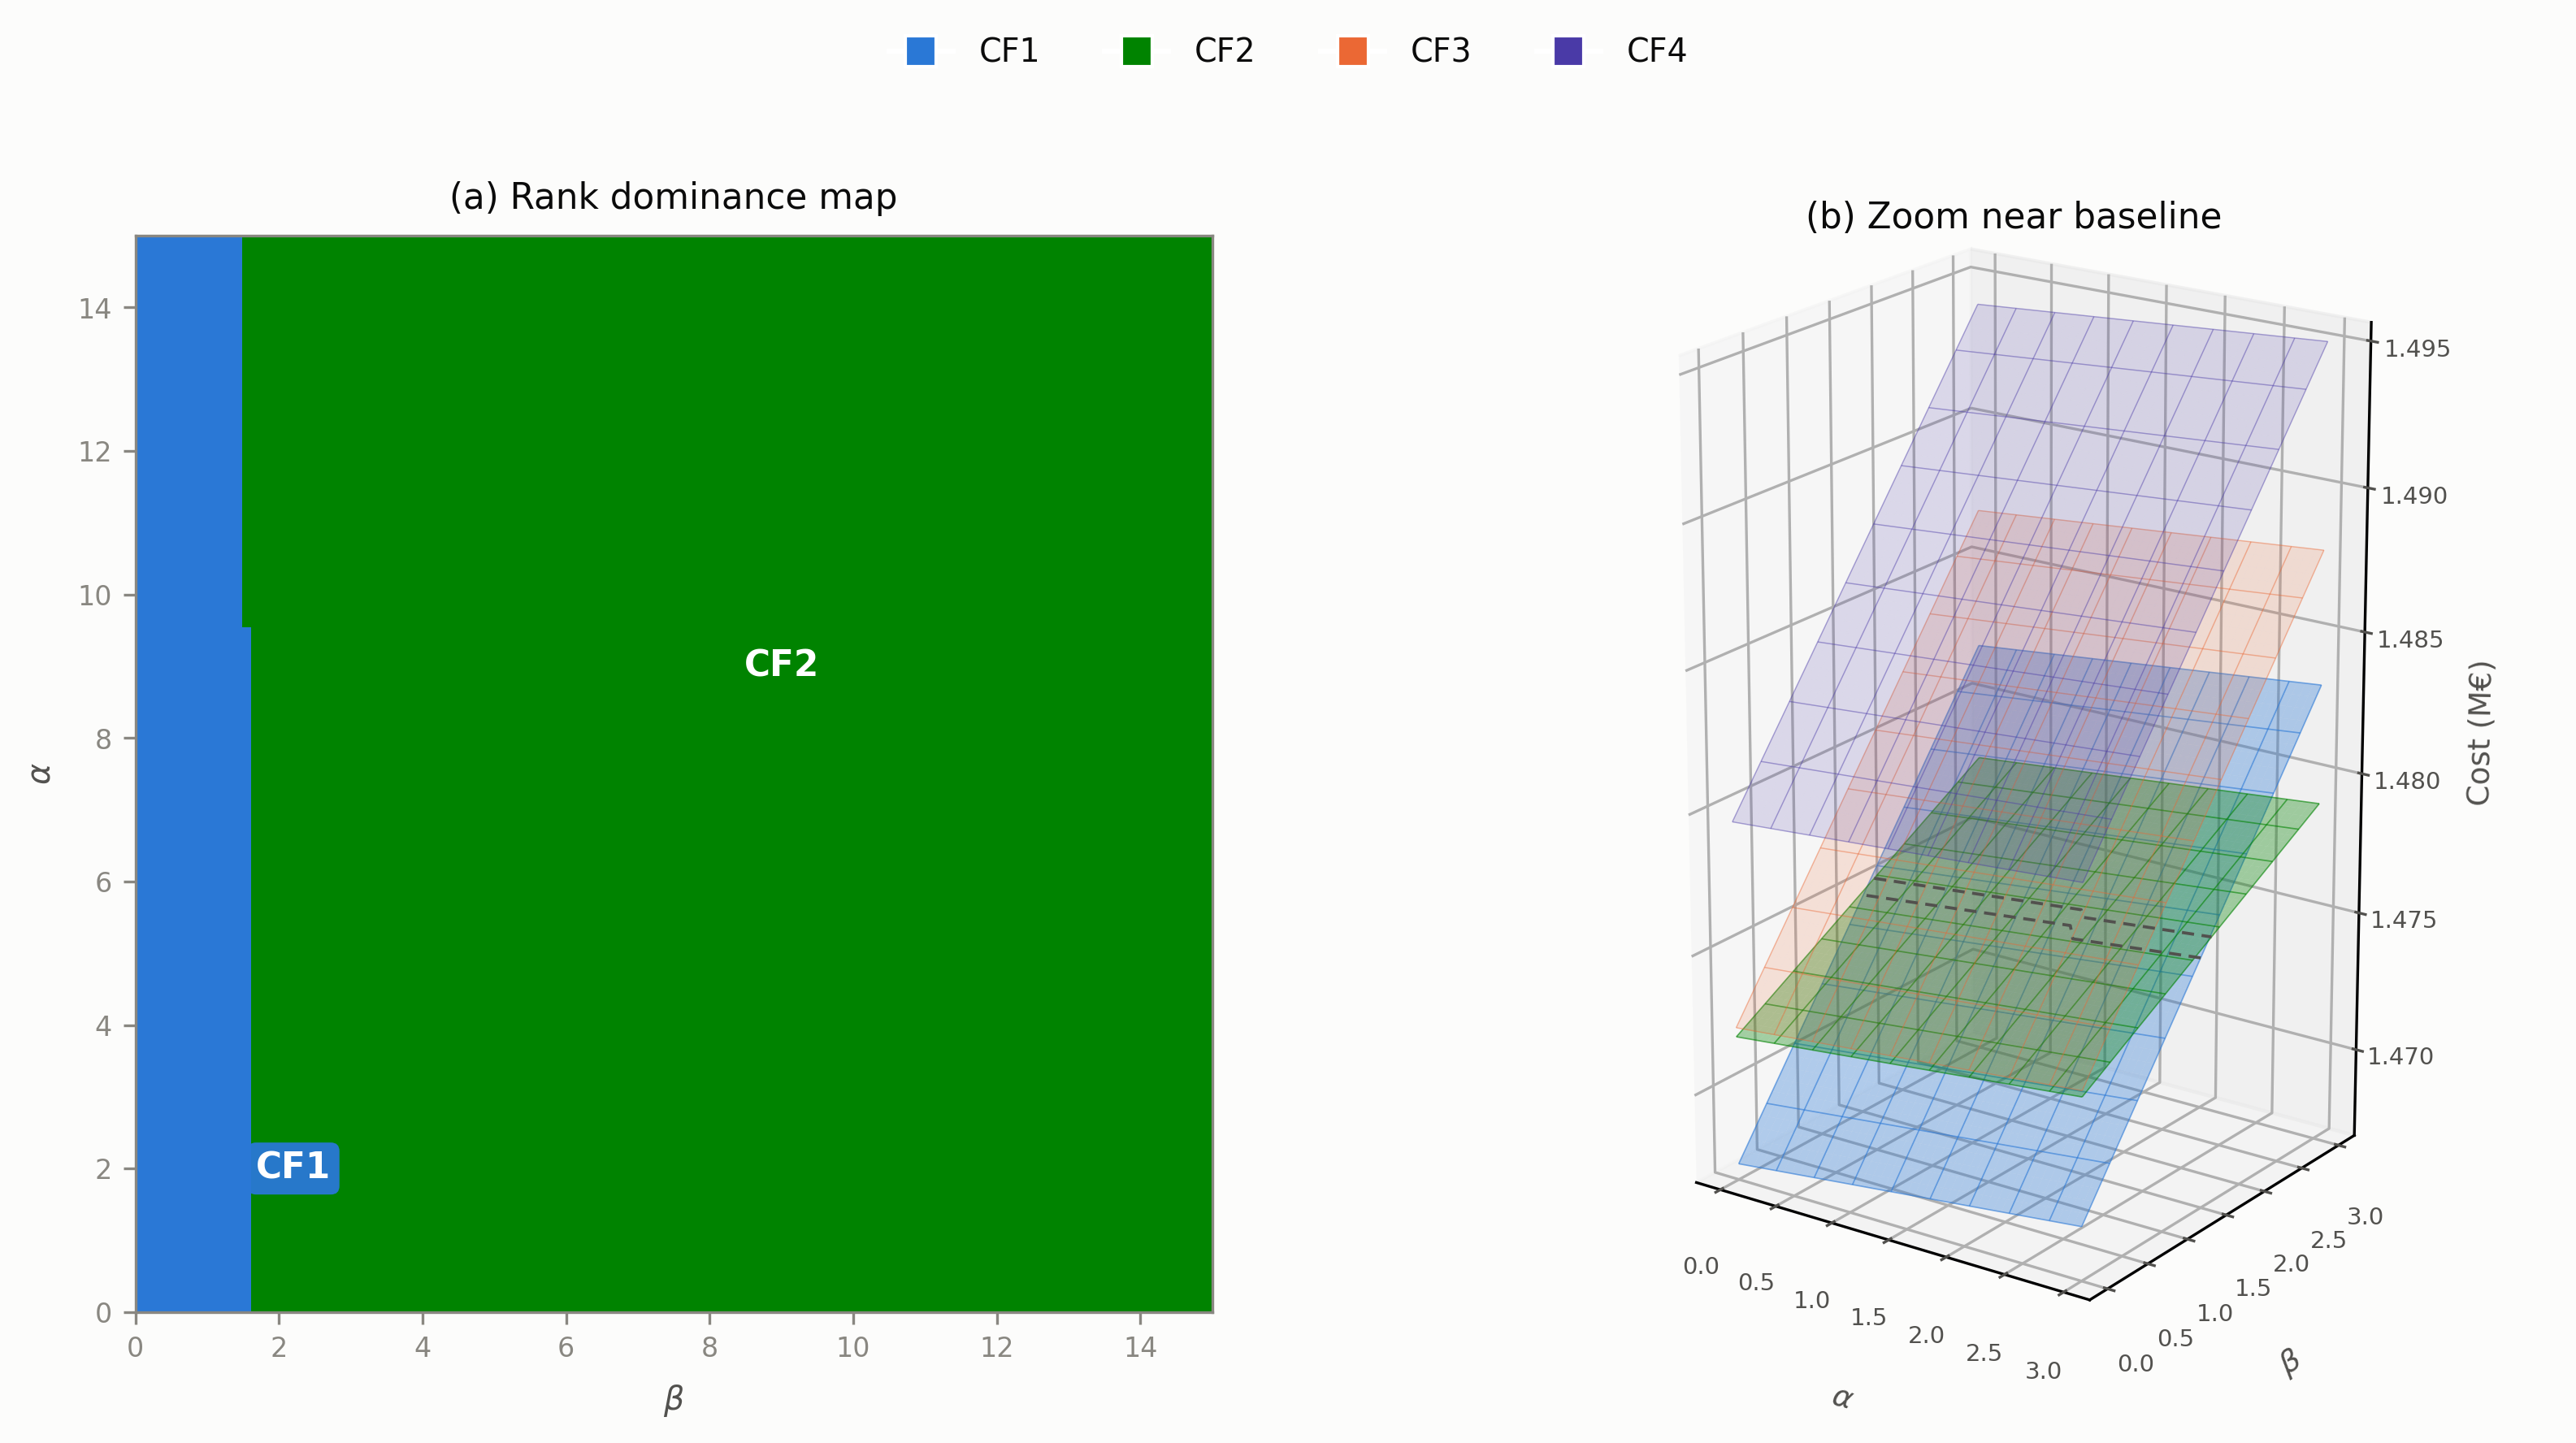

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.interpolate import RegularGridInterpolator

d_base_arr = base_durations_hours.squeeze().values
c_arr = df_costs.squeeze().values
d_opt_arr, d_pes_arr = d_base_arr * 0.8, d_base_arr * 1.2
denom_c_arr = np.where((d_base_arr - d_opt_arr) ** 2 == 0, 1, (d_base_arr - d_opt_arr) ** 2)
denom_e_arr = np.where((d_pes_arr - d_base_arr) ** 2 == 0, 1, (d_pes_arr - d_base_arr) ** 2)
D_arr = comparison_pool_dedup[dur_cols].values
CF_ID_arr = comparison_pool_dedup['CF_ID'].values

def cost_surface(cf_id, alphas, betas):
    Drow = comparison_pool_dedup.loc[comparison_pool_dedup.CF_ID == cf_id, dur_cols].values[0]
    compress = Drow < d_base_arr
    A, B = np.meshgrid(alphas, betas, indexing='ij')
    adj = np.where(compress[None, None, :],
                    1 + A[..., None] * (d_base_arr - Drow) / denom_c_arr,
                    1 + B[..., None] * (Drow - d_base_arr) / denom_e_arr)
    return (Drow * c_arr * adj).sum(axis=-1)

# Blue/green/orange/violet -- CVD-validated (validate_palette.js), avoids red-green pairing.
colors_map = {1: '#2a78d6', 2: '#008300', 3: '#eb6834', 4: '#4a3aa7'}
text_on = {1: 'white', 2: 'white'}
INK, INK_SEC, INK_MUTED, SURFACE = '#0b0b0b', '#52514e', '#898781', '#fcfcfb'
plt.rcParams['font.family'] = 'sans-serif'

def boundary_dashed_segments(abs_cost, A, B, active_ids):
    stack = np.stack([abs_cost[cf] for cf in active_ids], axis=0)
    winner_idx = np.argmin(stack, axis=0).astype(float)
    envelope = np.min(stack, axis=0) / 1e6
    boundary = np.zeros_like(winner_idx)
    boundary[:-1, :] = np.maximum(boundary[:-1, :], (winner_idx[:-1, :] != winner_idx[1:, :]))
    boundary[1:, :]  = np.maximum(boundary[1:, :],  (winner_idx[:-1, :] != winner_idx[1:, :]))
    boundary[:, :-1] = np.maximum(boundary[:, :-1], (winner_idx[:, :-1] != winner_idx[:, 1:]))
    boundary[:, 1:]  = np.maximum(boundary[:, 1:],  (winner_idx[:, :-1] != winner_idx[:, 1:]))
    tmp_fig, tmp_ax = plt.subplots()
    cs = tmp_ax.contour(A, B, boundary, levels=[0.5])
    segs = cs.allsegs[0] if cs.allsegs else []
    plt.close(tmp_fig)
    interp = RegularGridInterpolator((A[:, 0], B[0, :]), envelope, bounds_error=False, fill_value=None)
    return [(seg[:, 0], seg[:, 1], interp(seg)) for seg in segs if len(seg) >= 2]

def draw_3d(ax, alphas, betas, active_ids, fade_ids=(), wire_stride=6, fade_wire_stride=6, z_exaggerate=1.8):
    A, B = np.meshgrid(alphas, betas, indexing='ij')
    raw = {cf: cost_surface(cf, alphas, betas) for cf in set(active_ids) | set(fade_ids)}
    for cf in fade_ids:
        ax.plot_surface(A, B, raw[cf] / 1e6, color=colors_map[cf], alpha=0.16, linewidth=0, shade=False)
        ax.plot_wireframe(A, B, raw[cf] / 1e6, color=colors_map[cf], linewidth=0.35, alpha=0.45,
                            rstride=fade_wire_stride, cstride=fade_wire_stride)
    for cf in active_ids:
        ax.plot_surface(A, B, raw[cf] / 1e6, color=colors_map[cf], alpha=0.34, linewidth=0, shade=False)
        ax.plot_wireframe(A, B, raw[cf] / 1e6, color=colors_map[cf], linewidth=0.4, alpha=0.6,
                            rstride=wire_stride, cstride=wire_stride)
    for x, y, z in boundary_dashed_segments(raw, A, B, list(active_ids) + list(fade_ids)):
        ax.plot(x, y, z, color=INK_SEC, linewidth=0.9, linestyle=(0, (4, 2.5)), zorder=10)
    ax.set_xlabel(r'$\alpha$', fontsize=9, color=INK_SEC, labelpad=6)
    ax.set_ylabel(r'$\beta$', fontsize=9, color=INK_SEC, labelpad=6)
    ax.set_zlabel('Cost (M€)', fontsize=9, color=INK_SEC, labelpad=9)
    ax.tick_params(colors=INK_SEC, labelsize=7)
    ax.set_box_aspect((1, 1, z_exaggerate))

alphas_zoom = np.linspace(0, 3, 45)
betas_zoom  = np.linspace(0, 3, 45)

fig = plt.figure(figsize=(11.6, 5.6), dpi=300)
fig.patch.set_facecolor(SURFACE)

axD = fig.add_subplot(1, 2, 1)
axD.set_facecolor(SURFACE)
W = np.zeros((len(alphas_common), len(betas_common)), dtype=int)
for i, a in enumerate(alphas_common):
    for j, b in enumerate(betas_common):
        adj = np.where(D_arr < d_base_arr, 1 + a * (d_base_arr - D_arr) / denom_c_arr,
                        1 + b * (D_arr - d_base_arr) / denom_e_arr)
        cost = (D_arr * c_arr * adj).sum(axis=1)
        W[i, j] = CF_ID_arr[np.argmin(cost)]
winner_ids = sorted(np.unique(W).tolist())
cmap = ListedColormap([colors_map[w] for w in winner_ids])
idx_of = {w: i for i, w in enumerate(winner_ids)}
Widx = np.vectorize(idx_of.get)(W)
extent = [betas_common.min(), betas_common.max(), alphas_common.min(), alphas_common.max()]
axD.imshow(Widx, origin='lower', extent=extent, aspect='auto', cmap=cmap, interpolation='nearest', zorder=1)
label_pos = {1: (2.2, 2), 2: (9, 9)}
for cf, (bx, ay) in label_pos.items():
    if cf in winner_ids:
        axD.text(bx, ay, f'CF{cf}', fontsize=10.5, fontweight='bold', color=text_on[cf], ha='center', va='center',
                   zorder=6, bbox=dict(boxstyle='round,pad=0.24', fc=colors_map[cf], ec='none', alpha=0.95))
axD.set_xlabel(r'$\beta$', fontsize=9.5, color=INK_SEC, labelpad=6)
axD.set_ylabel(r'$\alpha$', fontsize=9.5, color=INK_SEC, labelpad=6)
axD.tick_params(colors=INK_MUTED, labelsize=8)
for spine in axD.spines.values():
    spine.set_color(INK_MUTED)
axD.set_title('(a) Rank dominance map', fontsize=10.5, color=INK, pad=8)
axD.set_box_aspect(1)

axC = fig.add_subplot(1, 2, 2, projection='3d')
axC.set_facecolor(SURFACE)
draw_3d(axC, alphas_zoom, betas_zoom, active_ids=[1, 2], fade_ids=[3, 4], wire_stride=5, fade_wire_stride=5)
axC.view_init(elev=20, azim=-55)
axC.set_title('(b) Zoom near baseline', fontsize=10.5, color=INK, pad=2)

handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors_map[cf], markersize=9, label=f'CF{cf}')
           for cf in [1, 2, 3, 4]]
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9.5, labelcolor=INK,
           bbox_to_anchor=(0.5, 1.04))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('../figures/sensitivity_analysis.pdf', facecolor=SURFACE, bbox_inches='tight')
plt.show()

#### Backup: full-landscape view (not in the manuscript)

A standalone wide-angle view of the same CF1/CF2 surfaces over the full common range, kept in the repo as a backup (`../figures/alpha_beta_view1_backup.pdf`) in case a reviewer or co-author wants the un-zoomed picture.

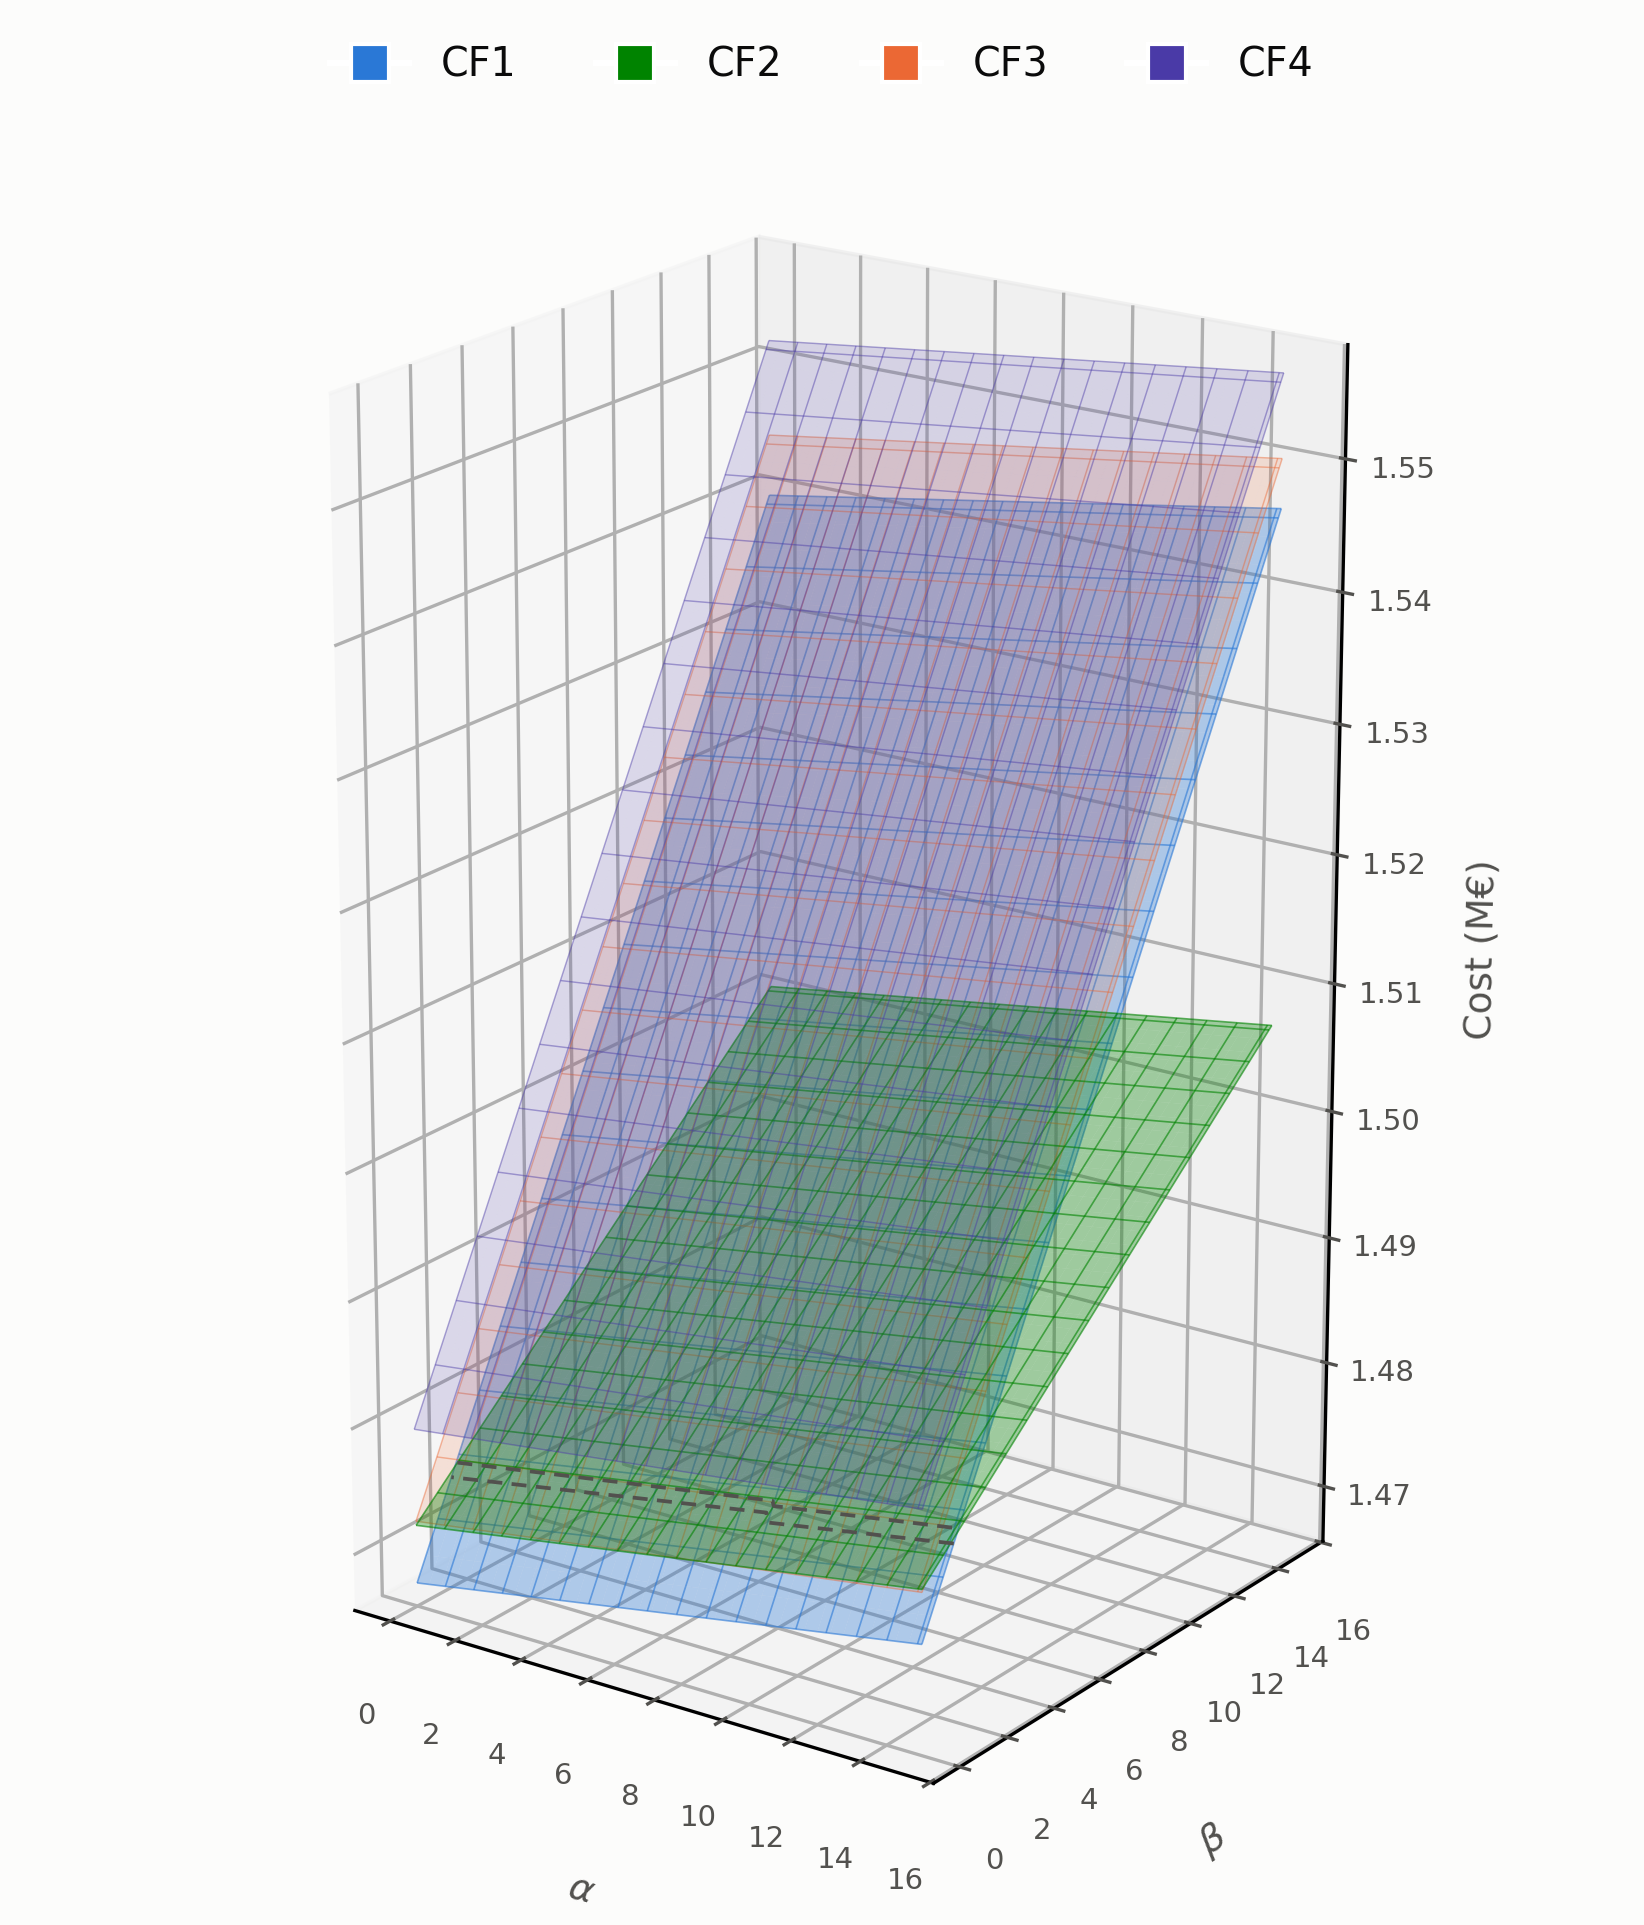

In [12]:
fig2 = plt.figure(figsize=(6.4, 6.0), dpi=300)
fig2.patch.set_facecolor(SURFACE)
ax1 = fig2.add_subplot(1, 1, 1, projection='3d')
ax1.set_facecolor(SURFACE)
draw_3d(ax1, alphas_common, betas_common, active_ids=[1, 2], fade_ids=[3, 4], wire_stride=7, fade_wire_stride=7)
ax1.view_init(elev=20, azim=-55)
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors_map[cf], markersize=9, label=f'CF{cf}')
           for cf in [1, 2, 3, 4]]
fig2.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9.5, labelcolor=INK,
            bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('../figures/alpha_beta_view1_backup.pdf', facecolor=SURFACE, bbox_inches='tight')
plt.show()